<a href="https://colab.research.google.com/github/thari1234-ai/NLP-SKILL/blob/main/NLP_TASK_1_SENTIMENT_ANALYSIS_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape:
(50000, 2)

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Count:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1

Cleaning Text...


/tmp/ipykernel_5366/3280060669.py:100: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace(


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  

Training Data: (40000,)
Testing Data: (10000,)

Converting Text into TF-IDF Features...
TF-IDF Completed

Training Logistic Regression Model...
Model Training Completed

MODEL PERFORMANCE
Accuracy : 0.889
Precision: 0.8796135265700483
Recall   : 0.9033538400476285
F1 Score : 0.8913256314861954

Classification Report
              

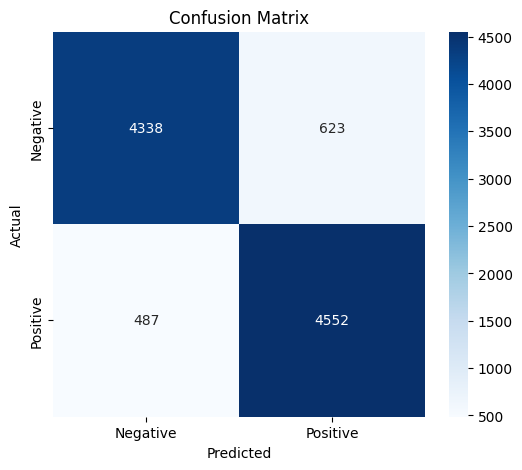


New Review Prediction

This movie was fantastic.
The acting was brilliant and the story was very interesting.
 ----> Positive Sentiment

This movie was boring.
The screenplay was bad and I wasted my time.
 ----> Negative Sentiment

Model Saved Successfully!


In [5]:
# ==========================================================
# Movie Review Sentiment Analysis using NLP
# Dataset: IMDb Dataset of 50K Movie Reviews
# Model: Logistic Regression + TF-IDF
# ==========================================================


# ==============================
# 1. Install Libraries (Colab)
# ==============================

# Uncomment this if running in Google Colab

# !pip install pandas numpy nltk scikit-learn matplotlib seaborn


# ==============================
# 2. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import re
import pickle

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns



# ==============================
# 3. Download NLTK Packages
# ==============================

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



# ==============================
# 4. Load Dataset
# ==============================

# Keep IMDB Dataset.csv in the same folder

df = pd.read_csv("IMDB Dataset.csv", on_bad_lines='skip')


print("Dataset Loaded Successfully")
print(df.head())

print("\nDataset Shape:")
print(df.shape)



# ==============================
# 5. Dataset Information
# ==============================

print("\nMissing Values:")
print(df.isnull().sum())


print("\nSentiment Count:")
print(df['sentiment'].value_counts())



# ==============================
# 6. Convert Sentiment Labels
# ==============================

# Positive = 1
# Negative = 0


df['sentiment'] = df['sentiment'].replace(
    {
        "positive":1,
        "negative":0
    }
)


print(df.head())



# ==============================
# 7. Text Preprocessing
# ==============================


stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()



def clean_text(text):

    # Convert lowercase
    text = text.lower()


    # Remove HTML tags
    text = re.sub("<.*?>"," ",text)


    # Remove punctuation and numbers
    text = re.sub("[^a-zA-Z]", " ", text)


    # Tokenization
    words = text.split()


    # Remove stopwords and Lemmatization

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]


    return " ".join(words)




# Apply preprocessing

print("\nCleaning Text...")

df['clean_review'] = df['review'].apply(clean_text)


print(df[['review','clean_review']].head())



# ==============================
# 8. Split Data
# ==============================


X = df['clean_review']

y = df['sentiment']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



# ==============================
# 9. TF-IDF Vectorization
# ==============================


print("\nConverting Text into TF-IDF Features...")


tfidf = TfidfVectorizer(
    max_features=5000
)


X_train_tfidf = tfidf.fit_transform(X_train)


X_test_tfidf = tfidf.transform(X_test)



print("TF-IDF Completed")



# ==============================
# 10. Train Machine Learning Model
# ==============================


print("\nTraining Logistic Regression Model...")


model = LogisticRegression(
    max_iter=1000
)


model.fit(
    X_train_tfidf,
    y_train
)


print("Model Training Completed")



# ==============================
# 11. Model Prediction
# ==============================


y_pred = model.predict(
    X_test_tfidf
)



# ==============================
# 12. Evaluation
# ==============================


accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)


recall = recall_score(
    y_test,
    y_pred
)


f1 = f1_score(
    y_test,
    y_pred
)



print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)



print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)




# ==============================
# 13. Confusion Matrix
# ==============================


cm = confusion_matrix(
    y_test,
    y_pred
)



plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")


plt.show()



# ==============================
# 14. New Review Prediction
# ==============================


def predict_review(review):


    cleaned_review = clean_text(review)


    vector = tfidf.transform(
        [cleaned_review]
    )


    prediction = model.predict(
        vector
    )


    if prediction[0] == 1:
        return "Positive Sentiment"

    else:
        return "Negative Sentiment"




# ==============================
# 15. Test New Reviews
# ==============================


review1 = """
This movie was fantastic.
The acting was brilliant and the story was very interesting.
"""


review2 = """
This movie was boring.
The screenplay was bad and I wasted my time.
"""



print("\nNew Review Prediction")


print(
    review1,
    "---->",
    predict_review(review1)
)


print(
    review2,
    "---->",
    predict_review(review2)
)




# ==============================
# 16. Save Model
# ==============================


pickle.dump(
    model,
    open("sentiment_model.pkl","wb")
)


pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl","wb")
)


print("\nModel Saved Successfully!")


In [3]:
import os

os.listdir()

['.config', 'IMDB Dataset.csv', '.ipynb_checkpoints', 'sample_data']